In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import NMF, PCA

import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

In [2]:
px_template = 'plotly_white'
doc_str = 'chunk_str'
token_pattern = r"(?u)\b\w[\w']*\b"
min_ngram = 1
max_ngram = 1

In [3]:
CHUNK = pd.read_csv("ajtzibab-CHUNK.csv").set_index("chunk_id")

In [4]:
count_engine = CountVectorizer(ngram_range=(min_ngram, max_ngram), token_pattern=token_pattern)
CTM = pd.DataFrame(count_engine.fit_transform(CHUNK[doc_str]).toarray(), 
                   index=CHUNK.index, 
                   columns=count_engine.get_feature_names_out())

In [5]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / len(CTM) 
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di
VOCAB.sample(10, weights='dh')

,n,grams,p,i,df,dp,di,dh
term_str,,,,,,,,
kejalow,2,1,0.000076,13.681074,2,0.033333,4.906891,0.163563
chokiitajik,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
tu'ik,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
taqatarij,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
xekamisax,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
rab'inaleb,10,1,0.000381,11.359146,8,0.133333,2.906891,0.387585
sakik,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
nimalolmet,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
xkich'ako,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448


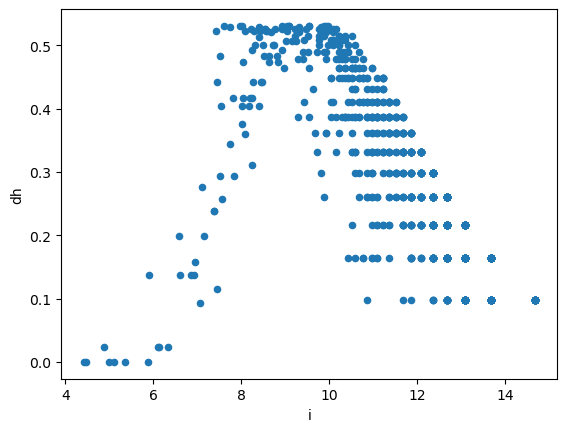

In [6]:
VOCAB.plot.scatter('i', 'dh')
plt.show()

In [7]:
# VOCAB.plot.scatter('i', 'di')
# plt.show()

In [8]:
stop_mask = VOCAB.dh < .2 # 
SIGS = VOCAB[~stop_mask].index.tolist()
stopwords = VOCAB[stop_mask].index.tolist()
len(SIGS)

777

In [9]:
CTMX = CTM[SIGS]
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

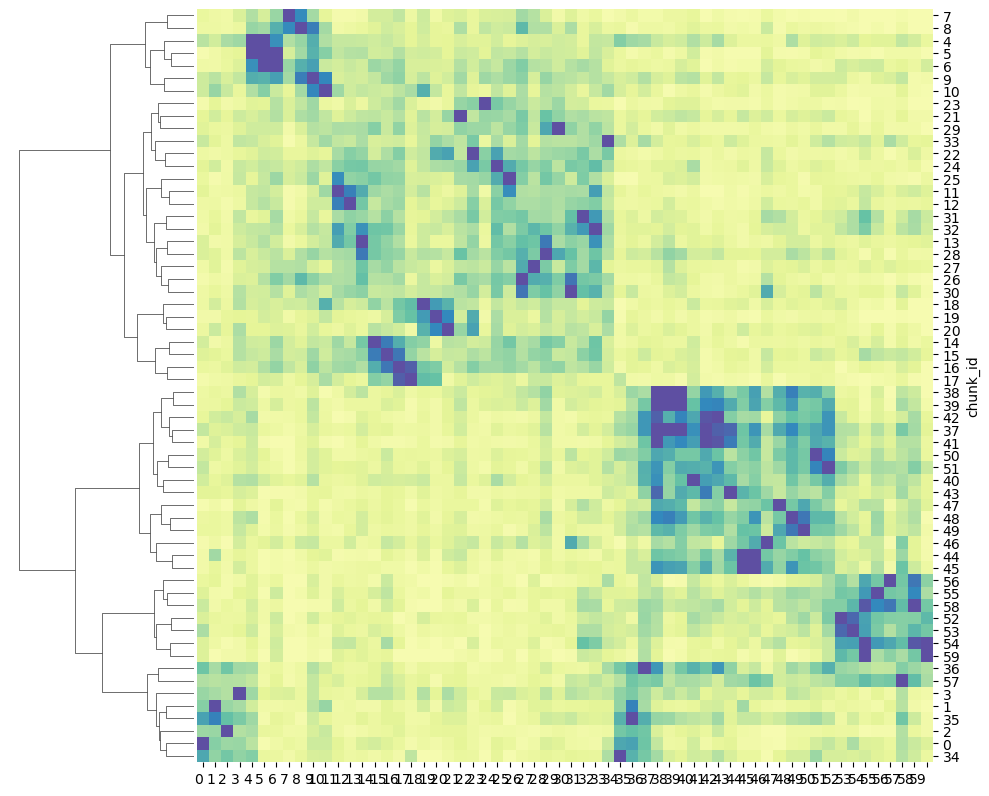

In [10]:
fig = sns.clustermap(TFIDF_SIM, 
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

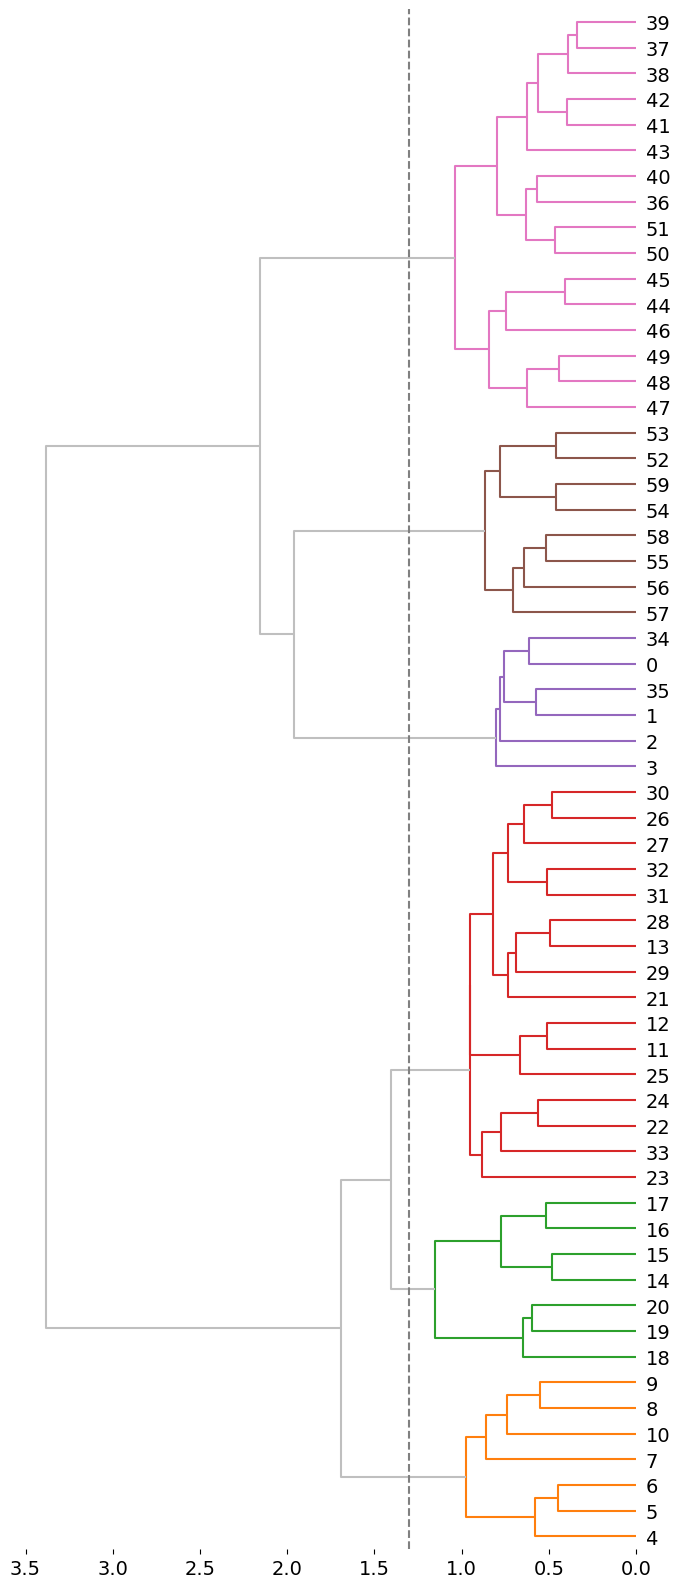

In [11]:
plt.figure(figsize=(8, len(TFIDF_SIM)/3))
tfidf_hac = HAC(TFIDF_SIM)
tfidf_hac.color_thresh = 1.3
tfidf_hac.plot()
sns.despine(left=True, bottom=True)
ax = plt.gca()
ax.axvline(tfidf_hac.color_thresh, c='gray', ls='--')
plt.show()

In [12]:
tfidf_hac.get_cluster_labels()

In [13]:
CHUNK['hac_label'] = tfidf_hac.CLUSTER_LABELS

In [14]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

In [15]:
CLUSTER = CHUNK.hac_label.value_counts().to_frame('n_chunks')

In [16]:
CLUSTER

,n_chunks
hac_label,
2,16
4,16
6,8
1,7
3,7
5,6


In [17]:
label_col = "hac_label"

In [18]:
CLUSTER['gloss'] = TFIDF.join(CHUNK[label_col]).groupby(label_col).mean().idxmax(1)
CLUSTER['top_terms'] = TFIDF.join(CHUNK[label_col]).groupby(label_col).mean().apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [19]:
CLUSTER.sort_index()

,n_chunks,gloss,top_terms
hac_label,,,
1,7,kaqix,"kaqix, k'ajolab, sipakna, wuqub, ajpu, kab'raq..."
2,16,xib'alb'a,"xib'alb'a, kame, ajpu, xcha, b'a, la, wuqub"
3,7,q'apoj,"q'apoj, che, ati't, b'atz, chowen, kati't, ix"
4,16,b'alam,"b'alam, tojil, amaq, k'itze, q'ij, majukutaj, ..."
5,6,kaj,"kaj, ulew, alom, k'ajolom, tz'aqol, b'itol, winaq"
6,8,ajaw,"ajaw, ajawab, ajpop, k'iche, tinamit, unim, q'..."


In [20]:
# pca_engine = PCA(n_components=k + (k % 2))
n_comps=5
pca_engine = PCA(n_components=n_comps)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'doc_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

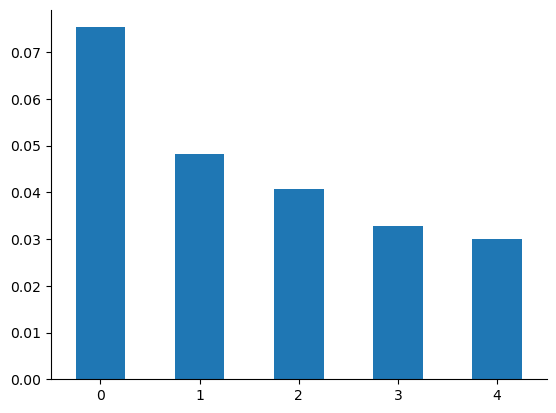

In [21]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0)
sns.despine()
plt.show()

In [22]:
X0 = CHUNK.join(PCAX).join(CLUSTER, on=label_col)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.gloss,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

In [23]:
plot_pca(0,1)

In [24]:
# X0

In [25]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss', 
           template=px_template,
           # height=400, width=600, 
           title=f'PC {i}').show()

In [26]:
for i in range(n_comps):
    comp_box(i)

In [27]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

In [28]:
with open("topics.md", "w") as outfile:
    TOPIC.to_markdown(outfile)

In [29]:
TOPIC['gloss'] = PHI.idxmax(1)

In [30]:
TOPIC

,top_terms,gloss
topic_id,,
0,"xib'alb'a, kame, ajpu, xcha, wuqub, naqi, ajaw...",xib'alb'a
1,"b'alam, tojil, amaq, k'itze, majukutaj, aq'ab,...",b'alam
2,"ajaw, ajawab, ajpop, aj, k'iche, tinamit, nim,...",ajaw
3,"kaj, ulew, winaq, uk'u'x, b'itol, tz'aqol, k'a...",kaj
4,"kaqix, k'ajolab, sipakna, wuqub, xcha, kab'raq...",kaqix
5,"kati't, q'apoj, che, ati't, chowen, b'atz, ajp...",kati't


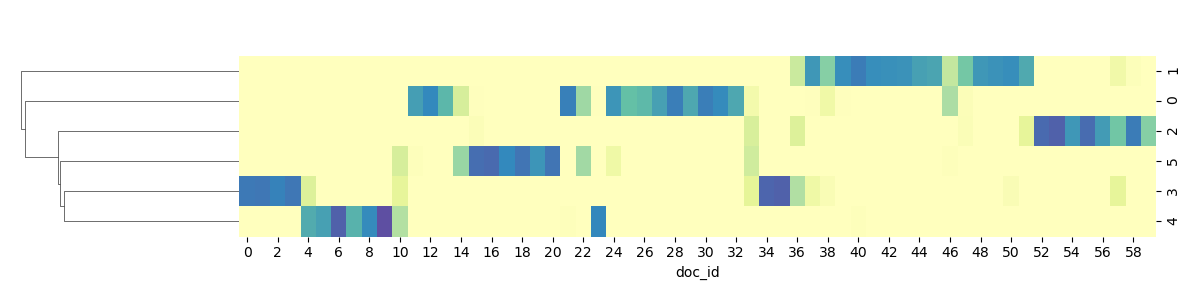

In [31]:
fig = sns.clustermap(THETA.T, 
    cmap='Spectral', 
    center=0, 
    metric='euclidean',
    method='ward', 
    cbar_pos=None,
    row_cluster=True, 
    col_cluster=False,
    figsize=(12,3)
)

In [32]:
R = THETA.T.corr().stack().sort_index().to_frame('r')

In [33]:
R.index.names = ['chunk_id_tmp', 'chunk_id']

In [34]:
RDIFF = R.query("chunk_id == chunk_id_tmp + 1") #.plot.barh(figsize=(2,10), legend=False);
RDIFF = RDIFF.reset_index().set_index('chunk_id').drop(columns=['chunk_id_tmp'])

In [35]:
RDIFF.style.bar()

,r
chunk_id,
1,1.000000
2,1.000000
3,1.000000
4,0.141573
5,0.941613
6,1.000000
7,1.000000
8,1.000000
9,1.000000


In [36]:
RDIFF2 = RDIFF.join(RDIFF.shift(-1), rsuffix='_next').join(RDIFF.shift(), rsuffix='_prev')
RDIFF2['novelty'] = RDIFF2.r - RDIFF2.r_prev
RDIFF2['transience'] = RDIFF2.r - RDIFF2.r_next
RDIFF2['resonance'] = (RDIFF2.novelty * RDIFF2.transience)

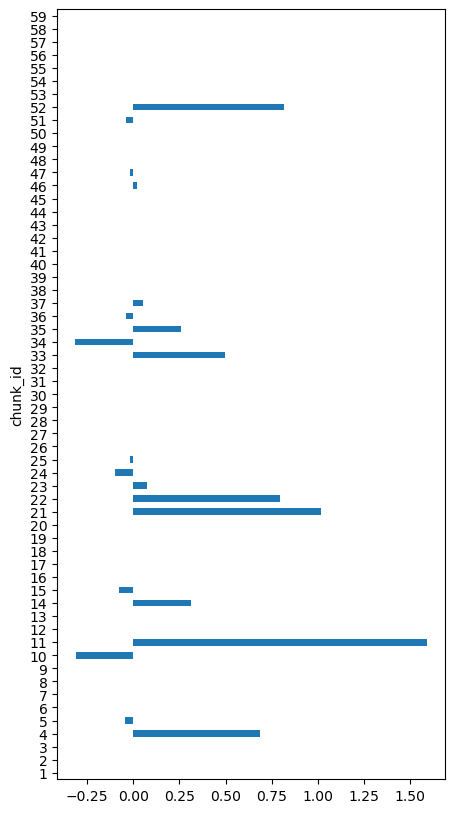

In [37]:
RDIFF2.resonance.plot.barh(figsize=(5,10));